<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/trabalho_1_metodos1_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questão 1

X1

In [ ]:

# C/ Barril + if (válido p/ P ≤ Pb e P > Pb - qualquer valor além da AP 01)
!pip install barril pandas numpy


import numpy as np
import pandas as pd
from dataclasses import dataclass
from barril.units import Scalar
def F_R(T_F):
    return Scalar(T_F,"degF").GetValue("degR")
def API(d_o):
    return 141.5/d_o-131.5
def pseudocrit_dg(d_g):
    P_pc=706.0-51.7*d_g-11.1*d_g**2
    T_pc=187.0+330.0*d_g-71.5*d_g**2
    return P_pc,T_pc
def Z_papay(P_psia,T_F,d_g):
    T_R=F_R(T_F)
    P_pc,T_pc=pseudocrit_dg(d_g)
    P_pr,T_pr=P_psia/P_pc,T_R/T_pc
    Z=1-3.53*P_pr/(10**(0.9813*T_pr))+0.274*(P_pr**2)/(10**(0.8157*T_pr))
    return Z,P_pc,T_pc,P_pr,T_pr
def R_s_Standing(P_psia,API_,T_F,d_g):
    return (((P_psia/18.2)+1.4)*(10**(0.0125*API_))/(10**(0.00091*T_F)))**(1/0.83)*d_g
def dR_s_dP_Standing(P_psia,API_,T_F,d_g):
    term=((P_psia/18.2)+1.4)
    expo=(1/0.83)-1
    coef=(1/(0.83*18.2))*d_g*(10**(0.0125*API_-0.00091*T_F))
    return coef*term**expo
def B_o_Standing(R_s,d_g,d_o,T_F):
    return 0.9759+0.00012*(R_s*(d_g/d_o)**0.5+1.25*T_F)**1.2
def dB_o_dP_Standing(R_s,dR_s_dP,d_g,d_o,T_F):
    base=R_s*(d_g/d_o)**0.5+1.25*T_F
    return 0.00012*1.2*(base**0.2)*((d_g/d_o)**0.5)*dR_s_dP
def B_g(Z,T_F,P_psia):
    return (14.7/60.0)*Z*(T_F/P_psia)
def μ_o_morto_BeggsRob(API_,T_F):
    A=10**(3.0324-0.02023*API_)
    return 10**(A*(T_F**(-1.163)))-1.0
def μ_o_sat_BeggsRob(R_s,μ_od):
    a=10.715*(R_s+100)**(-0.515)
    b=5.44*(R_s+150)**(-0.338)
    return a*(μ_od**b)
def μ_o_sat_Standing(R_s,μ_od):
    a=10**(-7.4e-4*R_s+2.2e-7*R_s**2)
    b=0.68/(10**(8.62e-5*R_s))+0.25/(10**(1.1e-3*R_s))+0.062/(10**(3.74e-3*R_s))
    return a*(μ_od**b)
def μ_o_sub_BealStanding(P,Pb,μ_ob):
    return μ_ob+(0.001*(P-Pb))*(0.024*μ_ob**1.6+0.038*μ_ob**0.56)
def μ_g_Lee(T_R,ρ_lbft3,M_g):
    Xv=3.448+986.4/T_R+0.01009*M_g
    Yv=2.4-0.2*Xv
    Kv=(9.379+0.0160*M_g)*(T_R**1.5)/(209.2+19.26*M_g+T_R)
    return 1e-4*Kv*np.exp(Xv*(ρ_lbft3/62.4)**Yv)
def ρ_gas(P_psia,T_F,Z,M_g):
    R_g=10.73
    T_R=F_R(T_F)
    return P_psia*M_g/(Z*R_g*T_R)
def ρ_oil(R_s,B_o,d_g,d_o):
    return (62.4*d_o+0.0136*R_s*d_g)/B_o
def C_g(P_psia, T_F, d_g):
    Z, P_pc, T_pc, P_pr, T_pr = Z_papay(P_psia, T_F, d_g)
    dZ_dPpr = (-3.53)/(10**(0.9813*T_pr)) + 2*(0.274*P_pr)/(10**(0.8157*T_pr))
    C_pr = (1/P_pr) - (1/Z)*dZ_dPpr
    C_gas = abs(C_pr / P_pc)
    return C_gas
def C_o(P_psia,T_F,d_g,d_o,API_,Z):
    R_s=R_s_Standing(P_psia,API_,T_F,d_g)
    dR_s_dP=dR_s_dP_Standing(P_psia,API_,T_F,d_g)
    B_o=B_o_Standing(R_s,d_g,d_o,T_F)
    dB_o_dP=dB_o_dP_Standing(R_s,dR_s_dP,d_g,d_o,T_F)
    B_g_=B_g(Z,T_F,P_psia)
    return -(1/B_o)*dB_o_dP+(B_g_/(B_o*5.615))*dR_s_dP
@dataclass
class BlackOil:
    P:np.ndarray
    T:np.ndarray
    d_g:float
    d_o:float
    Pb:float
    P_unit:str="psia"
    T_unit:str="degF"
    def calcular(self):
        P_vals=np.array([Scalar(p,self.P_unit).GetValue("psia") for p in np.atleast_1d(self.P)])
        T_vals=np.array([Scalar(t,self.T_unit).GetValue("degF") for t in np.atleast_1d(self.T)])
        Pb_psia=Scalar(self.Pb,self.P_unit).GetValue("psia")
        API_=API(self.d_o)
        M_g=28.96*self.d_g
        resultados=[]
        for P,T in zip(P_vals,T_vals):
            Z,P_pc,T_pc,P_pr,T_pr=Z_papay(P,T,self.d_g)
            if P>Pb_psia:
                regiao="Sub-saturada (P > Pb)"
                Rsb=R_s_Standing(Pb_psia,API_,T,self.d_g)
                Bob=B_o_Standing(Rsb,self.d_g,self.d_o,T)
                ρ_ob=ρ_oil(Rsb,Bob,self.d_g,self.d_o)
                μ_od=μ_o_morto_BeggsRob(API_,T)
                μ_ob_beggs=μ_o_sat_BeggsRob(Rsb,μ_od)
                μ_ob_stand=μ_o_sat_Standing(Rsb,μ_od)
                m = 2.6*(P**1.187)*(10**(-11.513 - 8.98e-5*P))
                μ_o_beggs = μ_ob_beggs*(P/Pb_psia)**m
                μ_o_stand=μ_o_sub_BealStanding(P,Pb_psia,μ_ob_stand)
                C_o_=1e-6*np.exp((ρ_ob+0.004347*(P-Pb_psia)-79.1)/(0.0007141*(P-Pb_psia)-12.938))
                B_o=Bob*np.exp(-C_o_*(P-Pb_psia))
                ρ_o=ρ_ob*np.exp(C_o_*(P-Pb_psia))
                R_s=Rsb
            else:
                regiao="Saturada (P ≤ Pb)"
                R_s=R_s_Standing(P,API_,T,self.d_g)
                B_o=B_o_Standing(R_s,self.d_g,self.d_o,T)
                ρ_o=ρ_oil(R_s,B_o,self.d_g,self.d_o)
                μ_od=μ_o_morto_BeggsRob(API_,T)
                μ_o_beggs=μ_o_sat_BeggsRob(R_s,μ_od)
                μ_o_stand=μ_o_sat_Standing(R_s,μ_od)
                if np.isclose(P,Pb_psia):
                    C_o_=1e-6*np.exp((ρ_o+0.004347*(P-Pb_psia)-79.1)/(0.0007141*(P-Pb_psia)-12.938))
                else:
                    C_o_=C_o(P,T,self.d_g,self.d_o,API_,Z)
            ρ_g=ρ_gas(P,T,Z,M_g)
            μ_g=μ_g_Lee(F_R(T),ρ_g,M_g)
            C_g_ = C_g(P, T, self.d_g)
            resultados.append({
                "Condição":f"|P={P:.0f} psia  T={T:.0f} °F|",
                "DADOS INICIAIS":"",
                "REGIÃO":regiao,
                "T_R [°R]":F_R(T),
                "°API [-]":API_,
                "M_g [lbm/lbmol]":M_g,
                "P_pc [psia]":P_pc,
                "T_pc [°R]":T_pc,
                "P_pr [-]":P_pr,
                "T_pr [-]":T_pr,
                "Z [-]":Z,
                "R_s [SCF/STB]":R_s,
                "B_o [bbl/STB]":B_o,
                "B_g [ft³/SCF]":B_g(Z,T,P),
                "PROPRIEDADES FINAIS":"",
                "ρ_o [lb/ft³]":ρ_o,
                "ρ_g [lb/ft³]":ρ_g,
                "μ_o [cP] (Beggs-Robinson)":μ_o_beggs,
                "μ_o [cP] (Standing / Beal-Standing)":μ_o_stand,
                "μ_g [cP]":μ_g,
                "C_o [psi⁻¹]":C_o_,
                "C_g [psi⁻¹]":C_g_})
        df_all=pd.DataFrame(resultados).set_index("Condição").T
        return df_all.round(9)
P_vet=np.array([3626,5000,1000])
T_vet=np.array([122,122,150])
d_g,d_o=0.84,0.86
Pb=5000
oil=BlackOil(P_vet,T_vet,d_g,d_o,Pb,P_unit="psia",T_unit="degF")
df=oil.calcular()
print("\nRESULTADOS")
print(df.to_string())



RESULTADOS
Condição                            |P=3626 psia  T=122 °F| |P=5000 psia  T=122 °F| |P=1000 psia  T=150 °F|
DADOS INICIAIS                                                                                             
REGIÃO                                    Saturada (P ≤ Pb)       Saturada (P ≤ Pb)       Saturada (P ≤ Pb)
T_R [°R]                                             581.67                  581.67                  609.67
°API [-]                                          33.034884               33.034884               33.034884
M_g [lbm/lbmol]                                     24.3264                 24.3264                 24.3264
P_pc [psia]                                       654.73984               654.73984               654.73984
T_pc [°R]                                          413.7496                413.7496                413.7496
P_pr [-]                                           5.538078                7.636621                1.527324
T_pr [-]        

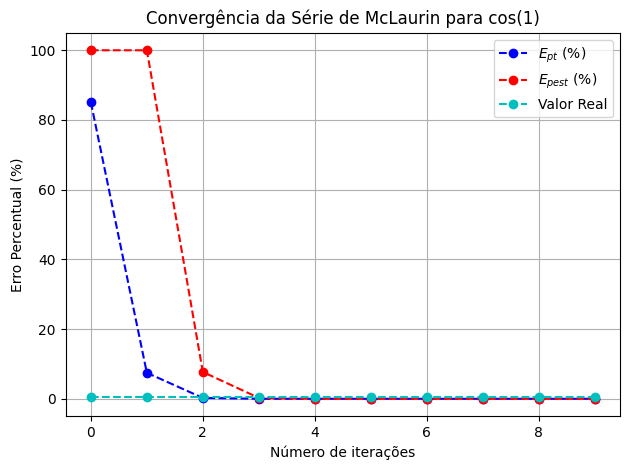

In [ ]:
#Grafico 1: Erro Percentual (verdadeiro e estimado) versus número de iterações
plt.plot(nn, EPT, 'o--', color='b', label='$E_{pt}$ (%)')
plt.plot(nn, EPEST, 'o--', color='r', label='$E_{pest}$ (%)')
plt.plot(nn, [math.cos(x1)] * len(table['n']), 'o--', color='c', label='Valor Real')
plt.xlabel('Número de iterações')
plt.ylabel('Erro Percentual (%)')
plt.title('Convergência da Série de McLaurin para cos(1)')
plt.tight_layout()
plt.grid()
plt.legend()
plt.show()

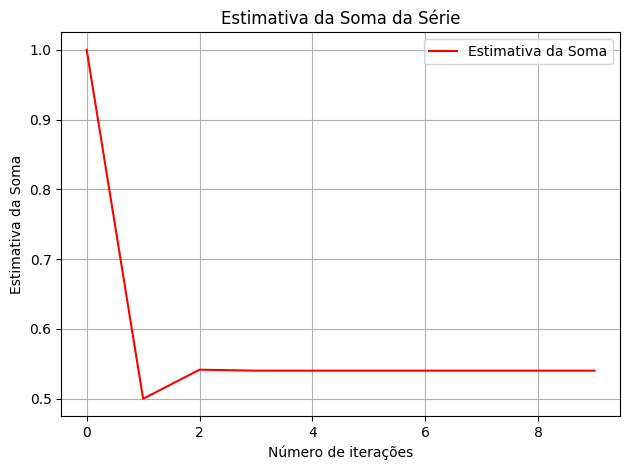

In [ ]:
# Gráfico 2: Estimativa da soma versus número de termos
plt.plot(nn, estimativa, label='Estimativa da Soma', color='r')
plt.xlabel('Número de iterações')
plt.ylabel('Estimativa da Soma')
plt.title('Estimativa da Soma da Série')
plt.tight_layout()
plt.grid()
plt.legend()
plt.show()

X2

In [ ]:
# Definindo o valor de x2
x2 = -2
# definindo a série
def serie_cos(x2, w):
  return ((-1)**w) * ((x2**(2*w))/math.factorial(2*w))

# Definindo variáveis
u2 = math.cos(x2)    # valor verdadeiro
soma2 = 0    #soma da serie começa em zero
v_old2 = soma2  #Armazena o valor anterior da soma, erro estimado
estimativa2 = []  # valores estimados da serie
EPT2 = []  # valor verdadeiro
EPEST2 = []  # valor estimado
nn2 = []  # numero de iteraçoes

for w in range(0, 10):
  soma2 = soma2 + serie_cos(x2, w)
  v_new2 = soma2  # atualiza para a iteração atual (soma)

  #Cálculo dos erros
  ept2 = abs(((u2 - soma2)/ u2) * 100)
  epest2 = abs(((v_new2 - v_old2)/ v_new2) * 100)

  v_old2 = v_new2
  estimativa2.append(soma2)
  EPT2.append(ept2)
  EPEST2.append(epest2)
  nn2.append(w)

# Data Frame
table = pd.DataFrame()
table['n'] = nn2
table['Estimativa'] = estimativa2
table['Ept'] = EPT2
table['Epest'] = EPEST2
print(table)


   n  Estimativa           Ept         Epest
0  0    1.000000  3.402998e+02  1.000000e+02
1  1   -1.000000  1.402998e+02  2.000000e+02
2  2   -0.333333  1.990007e+01  2.000000e+02
3  3   -0.422222  1.459914e+00  2.105263e+01
4  4   -0.415873  6.579905e-02  1.526718e+00
5  5   -0.416155  2.010414e-03  6.780810e-02
6  6   -0.416147  4.441820e-05  2.054833e-03
7  7   -0.416147  7.429495e-07  4.516115e-05
8  8   -0.416147  9.736342e-09  7.526858e-07
9  9   -0.416147  1.026861e-10  9.839028e-09


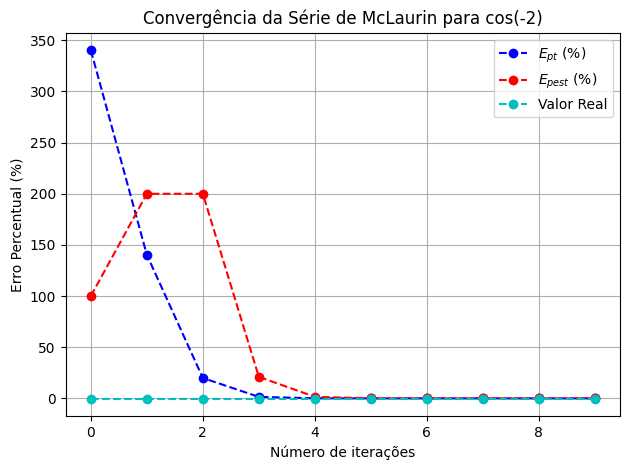

In [ ]:
#Gráfico 3: Erro Percentual (verdadeiro e estimado) versus número de iterações
plt.plot(table['n'], table['Ept'], 'o--', color='b', label='$E_{pt}$ (%)')
plt.plot(table['n'], table['Epest'], 'o--', color='r', label='$E_{pest}$ (%)')
plt.plot(table['n'], [math.cos(-2)] * len(table['n']), 'o--', color='c', label='Valor Real')
plt.xlabel('Número de iterações')
plt.ylabel('Erro Percentual (%)')
plt.title('Convergência da Série de McLaurin para cos(-2)')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

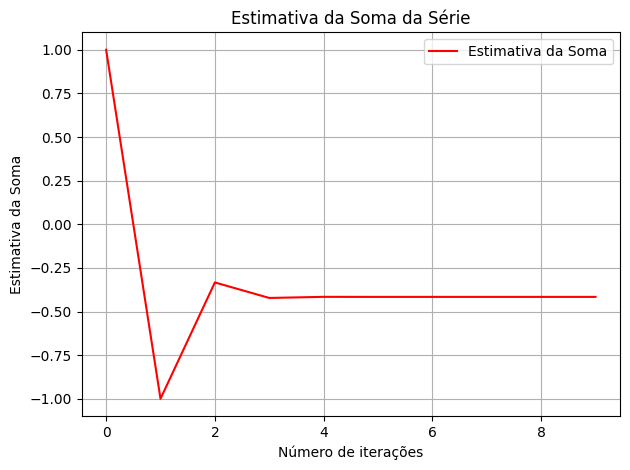

In [ ]:
# Gráfico 4: Estimativa da soma versus número de termos
plt.plot(nn2, estimativa2, label='Estimativa da Soma', color='r')
plt.xlabel('Número de iterações')
plt.ylabel('Estimativa da Soma')
plt.title('Estimativa da Soma da Série')
plt.tight_layout()
plt.grid()
plt.legend()
plt.show()

valor de cos(x): 0.5877852523
1 termo: aproximação = 1.0000000000, Erro percentual verdadeiro = 70.1301616704%
2 termo: aproximação = 0.5558678020, Erro percentual verdadeiro = 5.4301209867%
3 termo: aproximação = 0.5887433702, Erro percentual verdadeiro = 0.1630047502%
4 termo: aproximação = 0.5877699636, Erro percentual verdadeiro = 0.0026010649%
5 termo: aproximação = 0.5877854037, Erro percentual verdadeiro = 0.0000257520%
6 termo: aproximação = 0.5877852513, Erro percentual verdadeiro = 0.0000001736%


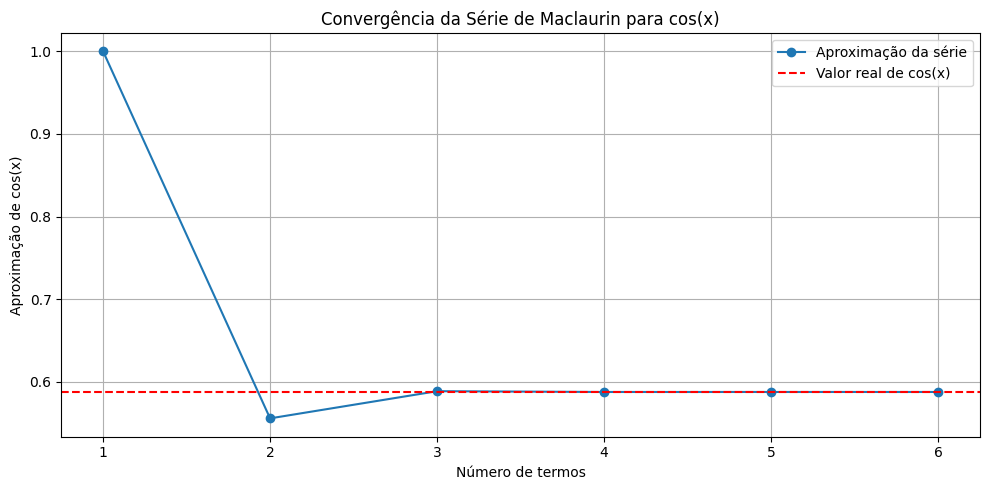

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

# Determinar o número de termos necessários para aproximar cos(x) com 8 algarismos significativos usando a série de Maclaurin

x = 0.3 * np.pi
u = np.cos(x)

n = 8
Eppara = 0.5 * 10**(2 - n)

i = 0
Ept = 100
soma = 0


def f(x, i):
    return (-1)**i * (x**(2*i)) / math.factorial(2*i)

print(f"valor de cos(x): {u:.10f}")

while Ept > Eppara:
    soma += f(x, i)
    i += 1
    Ept = abs((u - soma) / u) * 100
    print(f"{i} termo: aproximação = {soma:.10f}, Erro percentual verdadeiro = {Ept:.10f}%")

# Listas para armazenar os valores de aproximação e os erros em cada iteração
aproximacoes = []
erros = []

# Reinicializar variáveis
i = 0
Ept = 100
soma = 0

# Calcular novamente, agora armazenando os dados para o gráfico
while Ept > Eppara:
    soma += f(x, i)
    Ept = abs((u - soma) / u) * 100
    aproximacoes.append(soma)
    erros.append(Ept)
    i += 1

# Plotando o gráfico de aproximação
plt.figure(figsize=(10, 5))
plt.plot(range(1, i+1), aproximacoes, marker='o', label='Aproximação da série')
plt.axhline(y=u, color='r', linestyle='--', label='Valor real de cos(x)')
plt.title('Convergência da Série de Maclaurin para cos(x)')
plt.xlabel('Número de termos')
plt.ylabel('Aproximação de cos(x)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
